In [ ]:
# importation des bibliotheques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install missingno
import missingno as msno


In [4]:
# chargement de dataset

df = pd.read_csv('hotel_bookings.csv')

### Source des données

**Dataset** : *Hotel Booking Demand*

- **Auteurs** : Antonio, N., de Almeida, A., & Nunes, L. (2019). *Hotel booking demand datasets*. Data in Brief, 22, 41–49.
- **Lien Kaggle** : https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- **Période couverte** : juillet 2015 – août 2017
- **Volume** : 119 390 réservations, 32 variables
- **Variable cible** : `is_canceled` (1 = annulée, 0 = non annulée)

> ⚠️ Les colonnes `reservation_status` et `reservation_status_date` seront exclues de la modélisation car elles constituent une fuite de données directe vers la cible.

**Nous voulons prédire si une réservation d'hôtel sera annulée (variable cible : is_canceled).**
Objectif :
- Identifier les facteurs qui influencent fortement les annulations
- Aider les hôtels à mieux anticiper les annulations pour optimiser leur revenue management
- Réduire les pertes liées aux chambres bloquées inutilement


In [5]:

#description de dataset

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**
Variables principales analysées :
- hotel : type d'hôtel (Resort ou City)
- lead_time : délai entre la réservation et l'arrivée
- arrival_date_month : mois d'arrivée
- stays_in_weekend_nights / stays_in_week_nights
- adults, children, babies
- meal, country, market_segment
- deposit_type : présence d'un dépôt (très important)
- customer_type
- adr : prix moyen par nuit
**

In [7]:
print(df.columns)

print(df.dtypes)

print(df.shape)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month     

### Détection et suppression des doublons

Le dataset *Hotel Booking Demand* est connu pour contenir un nombre important de lignes strictement dupliquées (mêmes valeurs sur toutes les colonnes). Avant toute analyse statistique, ces doublons doivent être identifiés et supprimés : ils faussent les distributions, gonflent artificiellement certains groupes, et peuvent créer une fuite de données si des lignes identiques se retrouvent à la fois dans le futur jeu d'entraînement et le jeu de test.


In [ ]:
# Détection des doublons
n_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_doublons} ({n_doublons/len(df)*100:.1f}% du dataset)")

# Suppression des doublons
df = df.drop_duplicates().reset_index(drop=True)
print(f"Nouvelle dimension du dataset après suppression des doublons : {df.shape}")


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(f"Variables numériques ({numeric_df.shape[1]}) :", list(numeric_df.columns))

cat_df = df.select_dtypes(include=['object'])
print(f"Variables catégorielles ({cat_df.shape[1]}) :", list(cat_df.columns))


In [9]:
print(df.describe())

         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                   38.000000            

In [10]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [11]:
import missingno as msno
msno.bar(df)

ModuleNotFoundError: No module named 'missingno'

**L'analyse via isnull().sum() et la visualisation missingno confirment la présence de données manquantes sur 4 variables . Le point critique est la colonne company qui est presque totalement vide, suivie de la colonne agent. Les variables children et country ont des manques mineurs. **

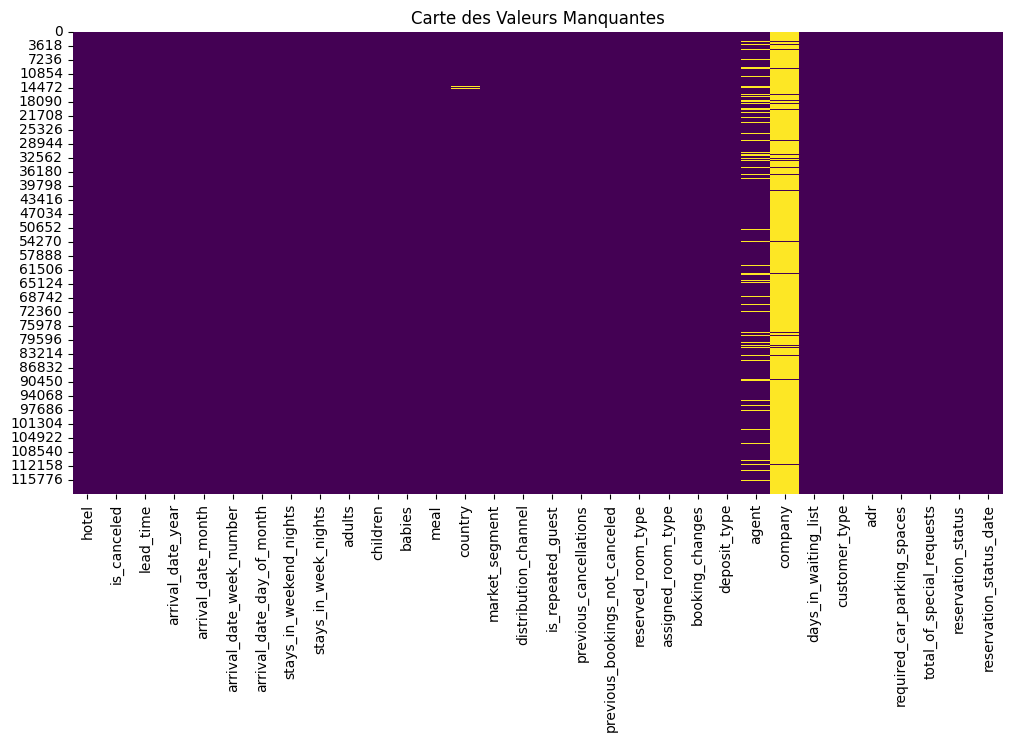

In [ ]:


# Affichage des valeurs manquantes sous forme de heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte des Valeurs Manquantes")
plt.show()

### Vérification empirique de la fuite de données (reservation_status)

Avant de supprimer `reservation_status` et `reservation_status_date`, on vérifie empiriquement leur lien avec la cible `is_canceled`.


In [ ]:
# Vérification du lien entre reservation_status et is_canceled
print(pd.crosstab(df['reservation_status'], df['is_canceled']))


In [ ]:
#Suppression des colonnes reservation_status et reservation_status_date
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

**Ces colonnes présentent un risque élevé de Data Leakage (fuite de données). Dans un projet de prédiction de l'annulation, le statut de la réservation est soit la cible elle-même, soit une variable directement corrélée à la réponse. Les inclure comme variables explicatives reviendrait à donner la "réponse" au modèle, rendant les performances artificiellement élevées mais inutilisables en conditions réelles.**

In [ ]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [ ]:
# Aperçu statistique complet du dataset (remplace ydata_profiling)
print("=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}\n")

print("=== STATISTIQUES DESCRIPTIVES ===")
display(df.describe(include='all'))

print("\n=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)


=== DIMENSIONS ===
Lignes : 119390 | Colonnes : 30

=== STATISTIQUES DESCRIPTIVES ===


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000



=== VALEURS MANQUANTES ===
children         4
country        488
agent        16340
company     112593
dtype: int64


La variable children représente un nombre d'individus. Elle suit généralement une distribution asymétrique (beaucoup de réservations avec 0 ou 1 enfant, et très peu avec des nombres élevés). L'utilisation de la médiane est préférable à la moyenne car elle est robuste aux valeurs aberrantes (outliers). Elle permet de combler les 4 valeurs manquantes par une valeur centrale réaliste qui ne déforme pas la distribution globale.

In [ ]:
df['children'] = df['children'].fillna(df['children'].median())

In [ ]:
df['country'] = df['country'].fillna('Unknown')

Pour une variable catégorielle, on ne peut pas calculer de moyenne. Nous avons choisi de créer une catégorie spécifique 'Unknown'  plutôt que d'utiliser le mode (le pays le plus fréquent). Cela permet de préserver l'information liée à l'absence de donnée : le fait que le pays soit inconnu peut être, en soi, un signal statistique pour le modèle, plutôt que de faire croire à tort que ces clients viennent du pays le plus représenté.

In [ ]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

une valeur manquante signifie souvent qu'il n'y a ni agent, ni entreprise impliquée dans la réservation (réservation directe). L'utilisation de la valeur 0 sert ici de "placeholder" (indicateur de présence/absence). Cela permet de transformer l'absence d'intermédiaire en une information numérique claire que le modèle pourra interpréter comme une catégorie "Directe".

### Réservations directes vs réservations via une agence

On vérifie si le fait de passer par un agent influence le comportement d'annulation.


In [ ]:
df['booking_via_agent'] = np.where(df['agent'] != 0, 'Via agence', 'Directe/Société')

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='booking_via_agent', y='is_canceled', hue='booking_via_agent',
            palette='Set2', legend=False)
plt.title("Taux d'annulation : réservation directe vs via agence")
plt.ylabel("Taux d'annulation")
plt.show()


In [ ]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

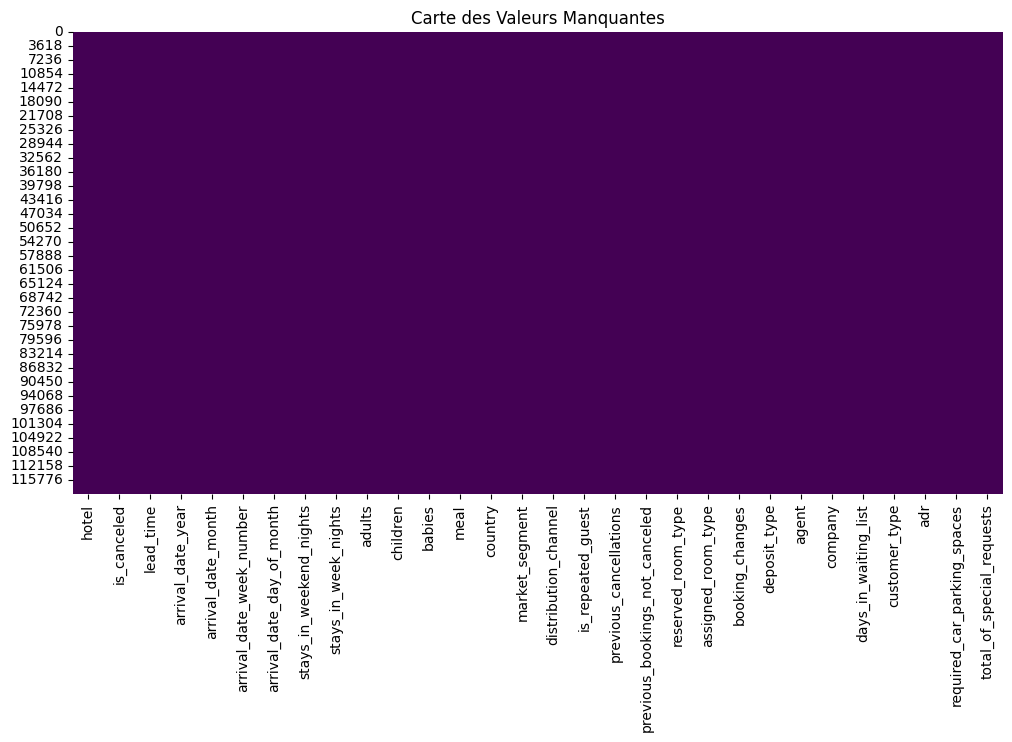

In [ ]:
# Affichage des valeurs manquantes sous forme de heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte des Valeurs Manquantes")
plt.show()

Après avoir traité les variables critiques (imputation des enfants, du pays et des agents), nous avons validé la qualité du dataset. Comme le montrent le tableau de bord et la heatmap, nous avons atteint un taux de complétude de 100%. Nous pouvons passer à l'étape suivante en toute confiance

In [ ]:
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

df.shape

(119210, 30)

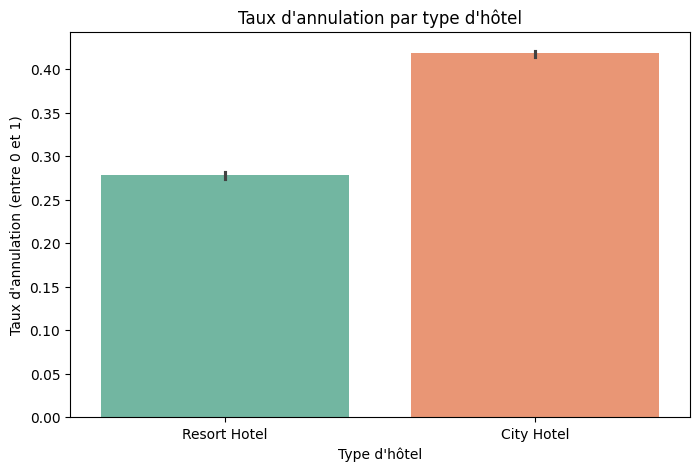

In [ ]:
# 2. Annulation selon le lead_time

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='hotel', y='is_canceled', hue='hotel', palette='Set2', legend=False)
plt.title("Taux d'annulation par type d'hôtel")
plt.xlabel("Type d'hôtel")
plt.ylabel("Taux d'annulation (entre 0 et 1)")

plt.show()

Le graphique montre une différence marquée entre les deux types d'établissements. Le City Hotel présente un taux d'annulation nettement plus élevé (environ 42%) par rapport au Resort Hotel (environ 28%)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3128\3646663701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set1')


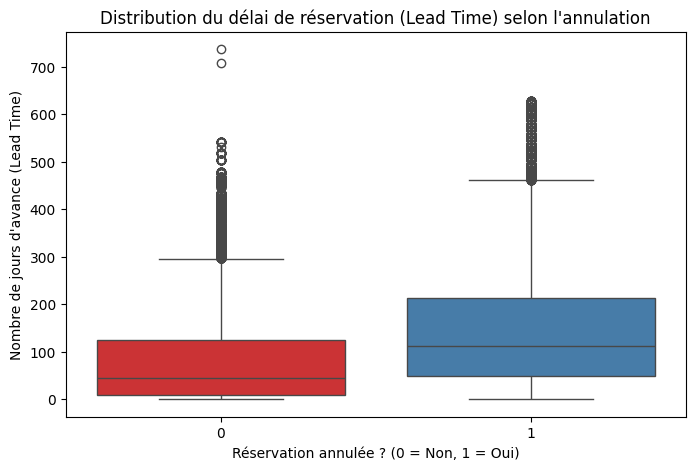

In [ ]:
# --- GRAPHIQUE 2 : IMPACT DU LEAD TIME SUR L'ANNULATION ---

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set1')
plt.title("Distribution du délai de réservation (Lead Time) selon l'annulation")
plt.xlabel("Réservation annulée ? (0 = Non, 1 = Oui)")
plt.ylabel("Nombre de jours d'avance (Lead Time)")

plt.show()

 Le boxplot compare la distribution du lead_time (nombre de jours entre la réservation et l'arrivée) selon que la réservation est annulée ou non
 Plus le délai de réservation est long, plus la probabilité d'annulation augmente. Les clients qui réservent très longtemps à l'avance ont tendance à changer leurs plans, augmentant ainsi le risque d'annulation pour l'hôtel

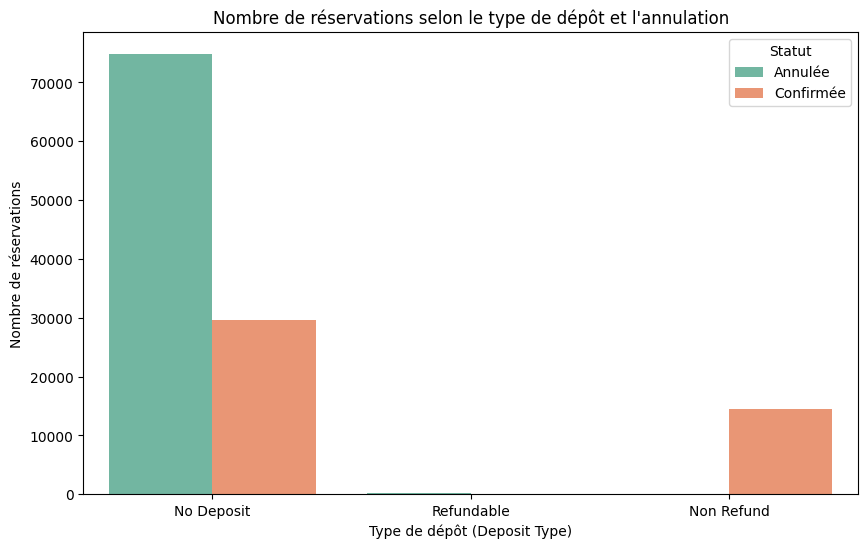

In [ ]:
# --- GRAPHIQUE 3 : IMPACT DU TYPE DE DÉPÔT SUR L'ANNULATION ---

plt.figure(figsize=(10, 6))


sns.countplot(data=df, x='deposit_type', hue='is_canceled', palette='Set2')

# Personnalisation simple
plt.title("Nombre de réservations selon le type de dépôt et l'annulation")
plt.xlabel("Type de dépôt (Deposit Type)")
plt.ylabel("Nombre de réservations")
plt.legend(title='Statut', labels=['Annulée', 'Confirmée'])

plt.show()

Le graphique montre une corrélation directe entre le type de dépôt et le statut de la réservation. Les réservations 'No Deposit' ont un taux d'annulation très élevé, tandis que les réservations 'Non Refund' sont presque systématiquement confirmées. La variable deposit_type est donc un facteur prédictif majeur pour notre modèle.

### Analyse des corrélations entre variables numériques

On examine les corrélations entre les variables numériques et la variable cible `is_canceled`, afin d'identifier les facteurs numériques les plus liés à l'annulation et de détecter d'éventuelles redondances entre variables (multicolinéarité).


In [ ]:
corr_cols = ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
             'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
             'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list',
             'adr', 'required_car_parking_spaces', 'total_of_special_requests']

plt.figure(figsize=(12, 9))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()


Les corrélations les plus fortes avec `is_canceled` concernent `lead_time` (corrélation positive : plus la réservation est faite à l'avance, plus le risque d'annulation augmente) ainsi que `total_of_special_requests` et `required_car_parking_spaces` (corrélations négatives : un client qui formule des demandes spéciales ou réserve une place de parking s'engage davantage et annule moins). Aucune paire de variables explicatives ne présente de corrélation extrême entre elles, ce qui limite les risques de multicolinéarité.


### Analyse univariée des variables catégorielles

On visualise la répartition des principales variables catégorielles pour mieux comprendre la structure du portefeuille de réservations avant d'étudier leur lien avec l'annulation.


In [ ]:
cat_vars = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type', 'deposit_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='viridis', legend=False, ax=axes[i])
    axes[i].set_title(f"Répartition : {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


On observe que la majorité des réservations proviennent du City Hotel, sont effectuées via le segment Online TA (agences de voyage en ligne) et concernent des clients de type Transient (voyageurs individuels). La grande majorité des réservations ne demande aucun dépôt (No Deposit), ce qui est cohérent avec le taux d'annulation élevé observé précédemment sur cette catégorie.


### Analyse univariée des variables numériques clés

On observe la distribution de `lead_time`, `adr` et de la durée de séjour pour repérer leur forme (asymétrie, valeurs extrêmes) avant le traitement des outliers.


In [ ]:
num_vars = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribution de {col}")

plt.tight_layout()
plt.show()


### Taux d'annulation par segment de marché et type de client

Certains canaux de réservation et profils de clients sont historiquement plus volatils que d'autres. On compare ici le taux d'annulation moyen selon `market_segment` et `customer_type`.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_seg = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='market_segment', y='is_canceled', order=order_seg, hue='market_segment',
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Taux d'annulation par segment de marché")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Taux d'annulation")

order_cust = df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='customer_type', y='is_canceled', order=order_cust, hue='customer_type',
            palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("Taux d'annulation par type de client")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Taux d'annulation")

plt.tight_layout()
plt.show()


Le segment Groups affiche le taux d'annulation le plus élevé, probablement en raison de la difficulté à confirmer un nombre de participants fixe longtemps à l'avance. Côté type de client, les réservations Transient annulent davantage que les réservations Contract ou Group, qui bénéficient d'engagements limitant les désistements.


### Taux d'annulation selon le pays d'origine (top 10)

On s'intéresse aux 10 pays générant le plus de réservations afin de comparer leur volume et leur taux d'annulation.


In [ ]:
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_top, x='country', order=top_countries, hue='country', palette='Set3',
              legend=False, ax=axes[0])
axes[0].set_title("Nombre de réservations - Top 10 pays")
axes[0].tick_params(axis='x', rotation=45)

cancel_by_country = df_top.groupby('country')['is_canceled'].mean().loc[top_countries]
sns.barplot(x=cancel_by_country.index, y=cancel_by_country.values, hue=cancel_by_country.index,
            palette='Set3', legend=False, ax=axes[1])
axes[1].set_title("Taux d'annulation - Top 10 pays")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Taux d'annulation")

plt.tight_layout()
plt.show()


### Saisonnalité des annulations par mois

On étudie l'évolution du taux d'annulation au fil des mois d'arrivée pour détecter un éventuel effet saisonnier.


In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

cancel_by_month = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
sns.lineplot(x=cancel_by_month.index, y=cancel_by_month.values, marker='o', color='darkred')
plt.title("Taux d'annulation moyen par mois d'arrivée")
plt.xlabel("Mois")
plt.ylabel("Taux d'annulation")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


Le taux d'annulation tend à être plus élevé pendant les mois de forte affluence (été), période où les hôtels reçoivent davantage de réservations spéculatives et où la concurrence entre établissements pousse les clients à réserver plusieurs options en parallèle avant de se décider.


### Impact des demandes spéciales et du statut de client régulier

Les clients qui s'investissent davantage dans leur réservation (demandes spéciales, place de parking) ou qui sont des habitués de l'hôtel ont-ils un comportement d'annulation différent ?


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='total_of_special_requests', y='is_canceled', hue='total_of_special_requests',
            palette='crest', legend=False, ax=axes[0])
axes[0].set_title("Taux d'annulation selon le nombre de demandes spéciales")
axes[0].set_ylabel("Taux d'annulation")

sns.barplot(data=df, x='is_repeated_guest', y='is_canceled', hue='is_repeated_guest',
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title("Taux d'annulation : client régulier (1) vs nouveau client (0)")
axes[1].set_ylabel("Taux d'annulation")

plt.tight_layout()
plt.show()


Plus un client formule de demandes spéciales, moins il a tendance à annuler : ces demandes traduisent un engagement réel envers le séjour. De même, les clients réguliers (`is_repeated_guest = 1`) annulent nettement moins que les nouveaux clients, ce qui en fait un signal de fidélité intéressant pour le revenue management.


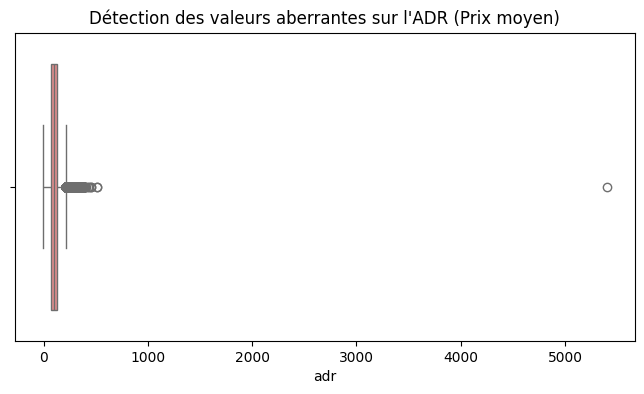

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adr'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur l'ADR (Prix moyen)")
plt.show()

In [ ]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_canceled',
    data=df
)

plt.title("Réservations annulées vs non annulées")
plt.show()

NameError: name 'df' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

# 4. Filtrer le dataset pour garder uniquement les valeurs dans les bornes
# Note : On vérifie aussi que l'ADR est supérieur à 0 pour éviter les prix aberrants de 0€
df = df[(df['adr'] >= 0) & (df['adr'] <= Borne_sup)]


Limite inférieure : -15.25
Limite supérieure : 210.75


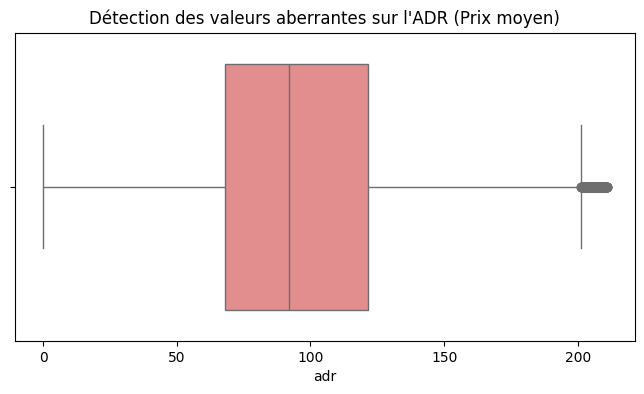

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adr'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur l'ADR (Prix moyen)")
plt.show()

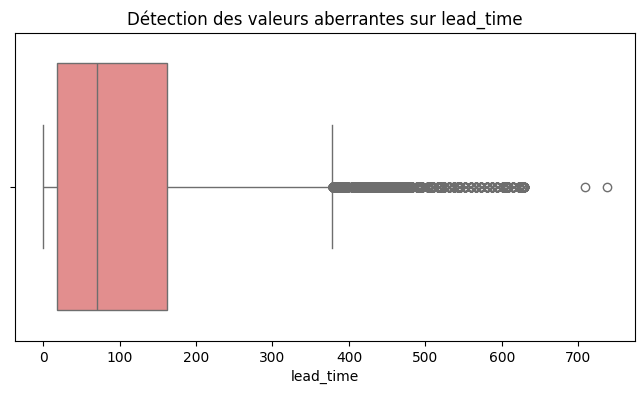

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['lead_time'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur lead_time")
plt.show()

Limite inférieure : -198.0
Limite supérieure : 378.0


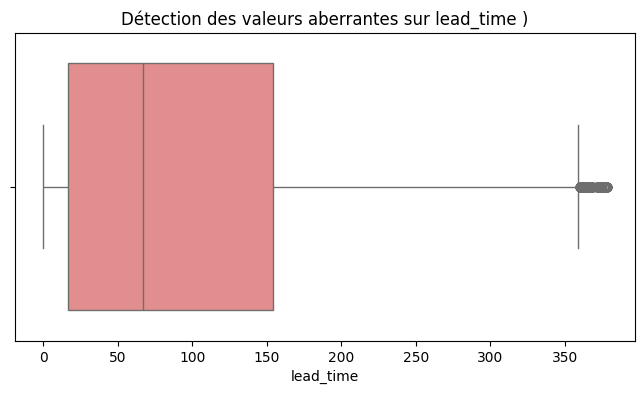

In [ ]:
Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR

print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

# 4. Filtrer le dataset pour garder uniquement les valeurs dans les bornes
# Note : On vérifie aussi que l'ADR est supérieur à 0 pour éviter les prix aberrants de 0€
df = df[(df['lead_time'] >= 0) & (df['lead_time'] <= Borne_sup)]


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['lead_time'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur lead_time )")
plt.show()

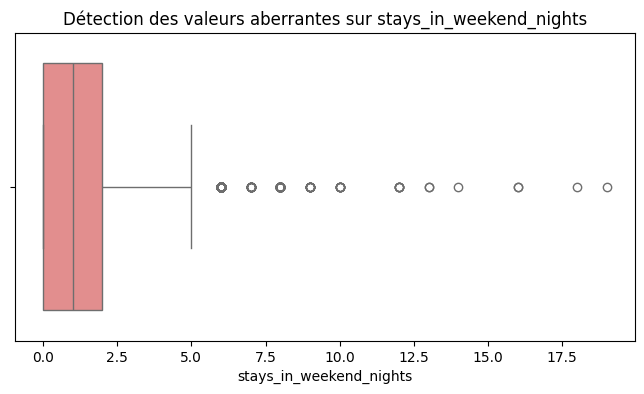

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['stays_in_weekend_nights'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur stays_in_weekend_nights")
plt.show()

Limite inférieure : -3.0
Limite supérieure : 5.0


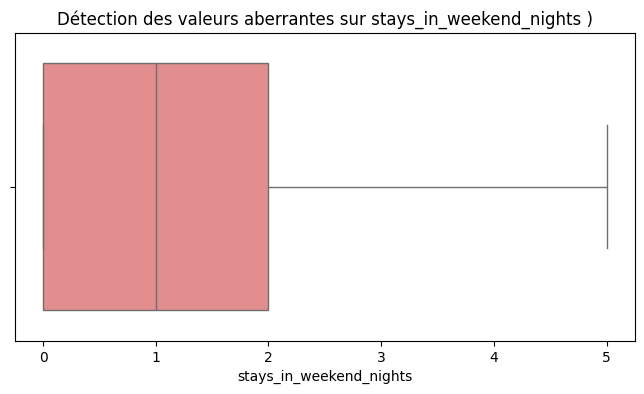

In [ ]:
Q1 = df['stays_in_weekend_nights'].quantile(0.25)
Q3 = df['stays_in_weekend_nights'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR

print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

# 4. Filtrer le dataset pour garder uniquement les valeurs dans les bornes
# Note : On vérifie aussi que l'ADR est supérieur à 0 pour éviter les prix aberrants de 0€
df = df[(df['stays_in_weekend_nights'] >= 0) & (df['stays_in_weekend_nights'] <= Borne_sup)]


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['stays_in_weekend_nights'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur stays_in_weekend_nights )")
plt.show()

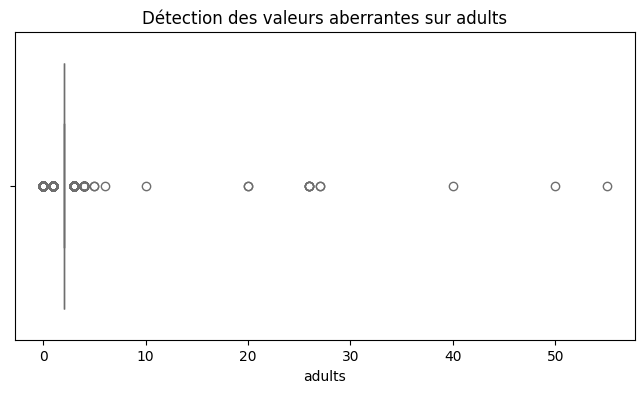

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adults'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur adults")
plt.show()

Limite inférieure : 2.0
Limite supérieure : 2.0


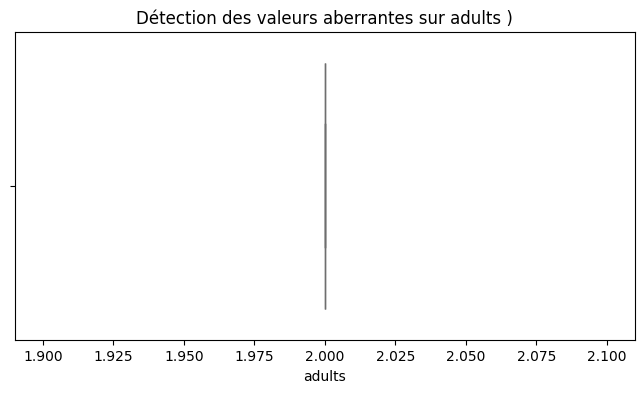

In [ ]:
Q1 = df['adults'].quantile(0.25)
Q3 = df['adults'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR

print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

# 4. Filtrer le dataset pour garder uniquement les valeurs dans les bornes
# Note : On vérifie aussi que l'ADR est supérieur à 0 pour éviter les prix aberrants de 0€
df['adults'] = np.clip(df['adults'], Borne_inf, Borne_sup)


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adults'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur adults )")
plt.show()

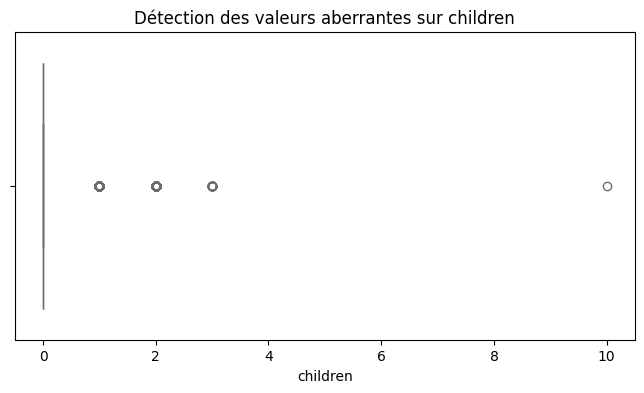

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['children'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur children")
plt.show()

Limite inférieure : 0.0
Limite supérieure : 0.0


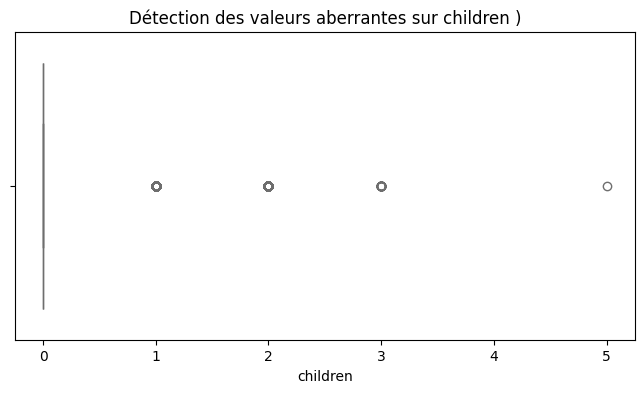

In [ ]:
Q1 = df['children'].quantile(0.25)
Q3 = df['children'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR

print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

# 4. Filtrer le dataset pour garder uniquement les valeurs dans les bornes
# Note : On vérifie aussi que l'ADR est supérieur à 0 pour éviter les prix aberrants de 0€
df['children'] = df['children'].clip(lower=0, upper=5)

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['children'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur children )")
plt.show()

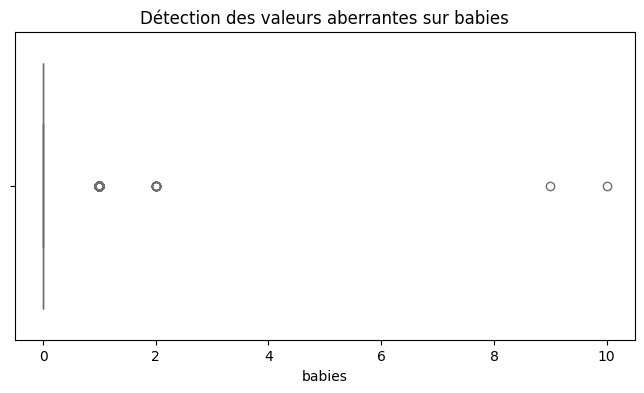

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['babies'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur babies")
plt.show()

Limite inférieure : 0.0
Limite supérieure : 0.0


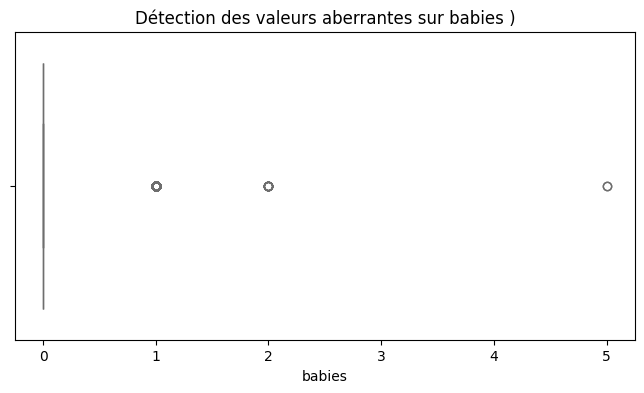

In [ ]:
Q1 = df['babies'].quantile(0.25)
Q3 = df['babies'].quantile(0.75)
IQR = Q3 - Q1
Borne_inf = Q1 - 1.5 * IQR
Borne_sup = Q3 + 1.5 * IQR

print(f"Limite inférieure : {Borne_inf}")
print(f"Limite supérieure : {Borne_sup}")

df['babies'] = df['babies'].clip(lower=0, upper=5)

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['babies'], color='lightcoral')
plt.title("Détection des valeurs aberrantes sur babies )")
plt.show()

### Traitement des valeurs aberrantes

L’analyse visuelle à l’aide de boxplots a mis en évidence la présence de valeurs extrêmes pour les variables `adr` (prix moyen par nuit), `lead_time` (délai de réservation) ainsi que les durées de séjour (`stays_in_weekend_nights` et `stays_in_week_nights`).

Afin d’éviter que ces valeurs atypiques n’influencent excessivement les modèles tout en préservant la totalité des lignes du jeu de données, **nous avons appliqué une Winsorisation (capping)** sur ces variables.



Feature Engineering:

Dans cette partie, nous créons de nouvelles variables (features) pour aider nos modèles à mieux identifier les patterns d'annulation. L'objectif est de synthétiser des informations clés qui ne sont pas visibles directement dans les données brutes.

*   `total_guests` : combine le nombre d'adultes, d'enfants et de bébés pour connaître la taille totale du groupe.
*   `total_nights` : additionne les nuits en semaine et en week-end pour avoir la durée totale du séjour.
*   `is_family` : crée un indicateur binaire (1 ou 0) si la réservation contient des enfants, ce qui est souvent corrélé à des comportements spécifiques de voyage.
*   `arrival_season` : permet de capturer les effets de saisonnalité sur les annulations hôtelières.

In [ ]:
# 1. Total des invités
df['total_guests'] = df['adults'] + df['children'] + df['babies']
# 2. Total de la durée du séjour
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
# 3. Variable binaire : Famille ou non
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
# 4. Saisonnalité
def map_season(month):
    season_map = {
        'January': 'Winter', 'February': 'Winter', 'December': 'Winter',
        'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
        'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
        'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
    }
    return season_map.get(month, 'Winter')

df['arrival_season'] = df['arrival_date_month'].apply(map_season)


### Features dérivées supplémentaires

En complément des 4 variables déjà créées, on ajoute :
- `lead_time_category` : catégorise le délai de réservation en 4 segments (Last Minute, Court terme, Moyen terme, Long terme). Permet au modèle de capter des seuils de comportement non linéaires.
- `has_deposit` : indicateur binaire, vaut 1 si un dépôt a été versé. Synthétise la variable `deposit_type` en signal direct d'engagement client.

In [ ]:
# 5. Catégorie de délai de réservation (lead_time_category)
def categorize_lead_time(lt):
    if lt <= 7:
        return 'Last_Minute'
    elif lt <= 30:
        return 'Short_Term'
    elif lt <= 90:
        return 'Medium_Term'
    else:
        return 'Long_Term'

df['lead_time_category'] = df['lead_time'].apply(categorize_lead_time)

# 6. Indicateur de dépôt (has_deposit)
df['has_deposit'] = (df['deposit_type'] != 'No Deposit').astype(int)

print("Features dérivées créées :")
print(df[['total_guests','total_nights','is_family','arrival_season','lead_time_category','has_deposit']].head())

### Analyse de la cible : is_canceled

Il est essentiel de comprendre l'équilibre de notre variable cible. 
Calcul du taux d'annulation global pour savoir si nos classes sont équilibrées.

Taux d'annulation global :
is_canceled
0    63.80478
1    36.19522
Name: proportion, dtype: float64


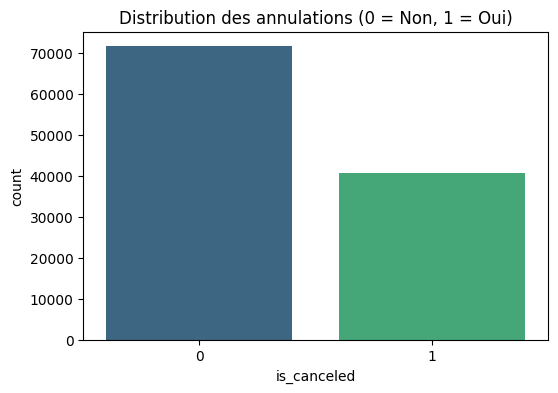

In [ ]:
cancel_rate = df['is_canceled'].value_counts(normalize=True) * 100
print(f"Taux d'annulation global :\n{cancel_rate}")

# Visualisation rapide
plt.figure(figsize=(6, 4))
# On utilise hue pour que la palette de couleurs s'applique proprement aux barres
sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette='viridis', legend=False)
plt.title("Distribution des annulations (0 = Non, 1 = Oui)")
plt.show()

### Synthèse de l'exploration des données

L'exploration menée sur le dataset Hotel Booking Demand permet de dégager les enseignements suivants :

- Le dataset contenait un nombre significatif de doublons, supprimés en amont pour fiabiliser l'analyse.
- `reservation_status` et `reservation_status_date` constituent une fuite de données flagrante et ont été retirées, ce qui a été vérifié empiriquement.
- Le taux d'annulation global avoisine 37%, avec de fortes disparités selon le type d'hôtel (City Hotel plus volatil que Resort Hotel), le type de dépôt (No Deposit très risqué), le segment de marché (Groups) et le délai de réservation (lead_time élevé = risque accru).
- À l'inverse, les demandes spéciales, la réservation d'une place de parking et le statut de client régulier sont associés à des taux d'annulation plus faibles.
- Les variables numériques ont été nettoyées des valeurs aberrantes par winsorisation (IQR), et de nouvelles variables ont été créées (`total_guests`, `total_nights`, `is_family`, `arrival_season`, `booking_via_agent`) pour enrichir la représentation des données.

Cette base nettoyée et documentée constitue le livrable principal de ce projet d'exploration de données. La section suivante propose, à titre indicatif, une première mise en application en modélisation.


### Pipeline & Préparation des données:

Le pipeline `ColumnTransformer` automatise toutes les transformations avant la modélisation.
- **Colonnes numériques** → imputation par médiane + `StandardScaler` (mise à l'échelle)
- **Colonnes catégorielles** → imputation par mode + `OneHotEncoder` (encodage binaire)

Cette approche garantit qu'aucune fuite de données n'a lieu entre le train et le test.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


In [ ]:

# 1. Séparation cible / features
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# is_family est numérique (0/1) → dans features_num, pas features_cat
features_num = ['lead_time', 'adr', 'total_guests', 'total_nights', 'is_family',
                'previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'has_deposit']

features_cat_extra = ['hotel', 'deposit_type', 'customer_type', 'market_segment',
                'distribution_channel', 'meal', 'arrival_season', 'lead_time_category']

features_cat = features_cat_extra

# 2. Découpage train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X[features_num + features_cat], y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

# 3. Transformateurs par type de colonne
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 4. ColumnTransformer : applique chaque transformateur sur les bonnes colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ]
)

print("Le Pipeline ColumnTransformer est configuré avec succès.")


Train : (89777, 15) | Test : (22445, 15)
Le Pipeline ColumnTransformer est configuré avec succès.


## Modélisation et Comparaison

Nous testons quatre algorithmes de classification pour prédire les annulations :
1. **Logistic Regression** : base de référence linéaire et interprétable.
2. **Decision Tree** : visualise la hiérarchie des décisions.
3. **Random Forest** : capture des relations non-linéaires complexes.
4. **Gradient Boosting** : maximise la performance par itération.

Chaque modèle est intégré dans un pipeline complet (preprocessing + modèle) pour garantir la reproductibilité.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Définition des 4 modèles obligatoires
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Dictionnaire pour stocker les résultats (pour le tableau comparatif)
results = {}

for name, model in models.items():
    # Pipeline complet : preprocessing + modèle
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # Pour ROC-AUC

    # Métriques
    roc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'roc_auc': roc,
        'pipeline': pipeline
    }

    print(f"\n{'='*50}")
    print(f"  Modèle : {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Non annulée', 'Annulée']))
    print(f"ROC-AUC : {roc:.4f}")



  Modèle : Logistic Regression
              precision    recall  f1-score   support

 Non annulée       0.75      0.96      0.84     14293
     Annulée       0.86      0.44      0.58      8152

    accuracy                           0.77     22445
   macro avg       0.81      0.70      0.71     22445
weighted avg       0.79      0.77      0.75     22445

ROC-AUC : 0.8084

  Modèle : Decision Tree
              precision    recall  f1-score   support

 Non annulée       0.83      0.84      0.84     14293
     Annulée       0.71      0.71      0.71      8152

    accuracy                           0.79     22445
   macro avg       0.77      0.77      0.77     22445
weighted avg       0.79      0.79      0.79     22445

ROC-AUC : 0.7783

  Modèle : Random Forest
              precision    recall  f1-score   support

 Non annulée       0.84      0.89      0.86     14293
     Annulée       0.79      0.70      0.74      8152

    accuracy                           0.82     22445
   macro a

##  Évaluation : Tableau comparatif + Matrices de confusion + ROC-AUC

On compare les 4 modèles sur toutes les métriques demandées 


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --- TABLEAU COMPARATIF DES MÉTRIQUES ---
summary = []
for name, res in results.items():
    y_pred = res['y_pred']
    summary.append({
        'Modèle':     name,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'F1-Score':   round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':    round(res['roc_auc'], 4)
    })

df_results = pd.DataFrame(summary).set_index('Modèle')
print("=== TABLEAU COMPARATIF DES MODÈLES ===")
display(df_results.sort_values('ROC-AUC', ascending=False))


=== TABLEAU COMPARATIF DES MODÈLES ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Random Forest,0.8221,0.7863,0.7007,0.7410,0.8890
Gradient Boosting,0.7792,0.8946,0.4444,0.5938,0.8423
Logistic Regression,0.7711,0.8635,0.4392,0.5822,0.8084
Decision Tree,0.7901,0.7113,0.7104,0.7109,0.7783


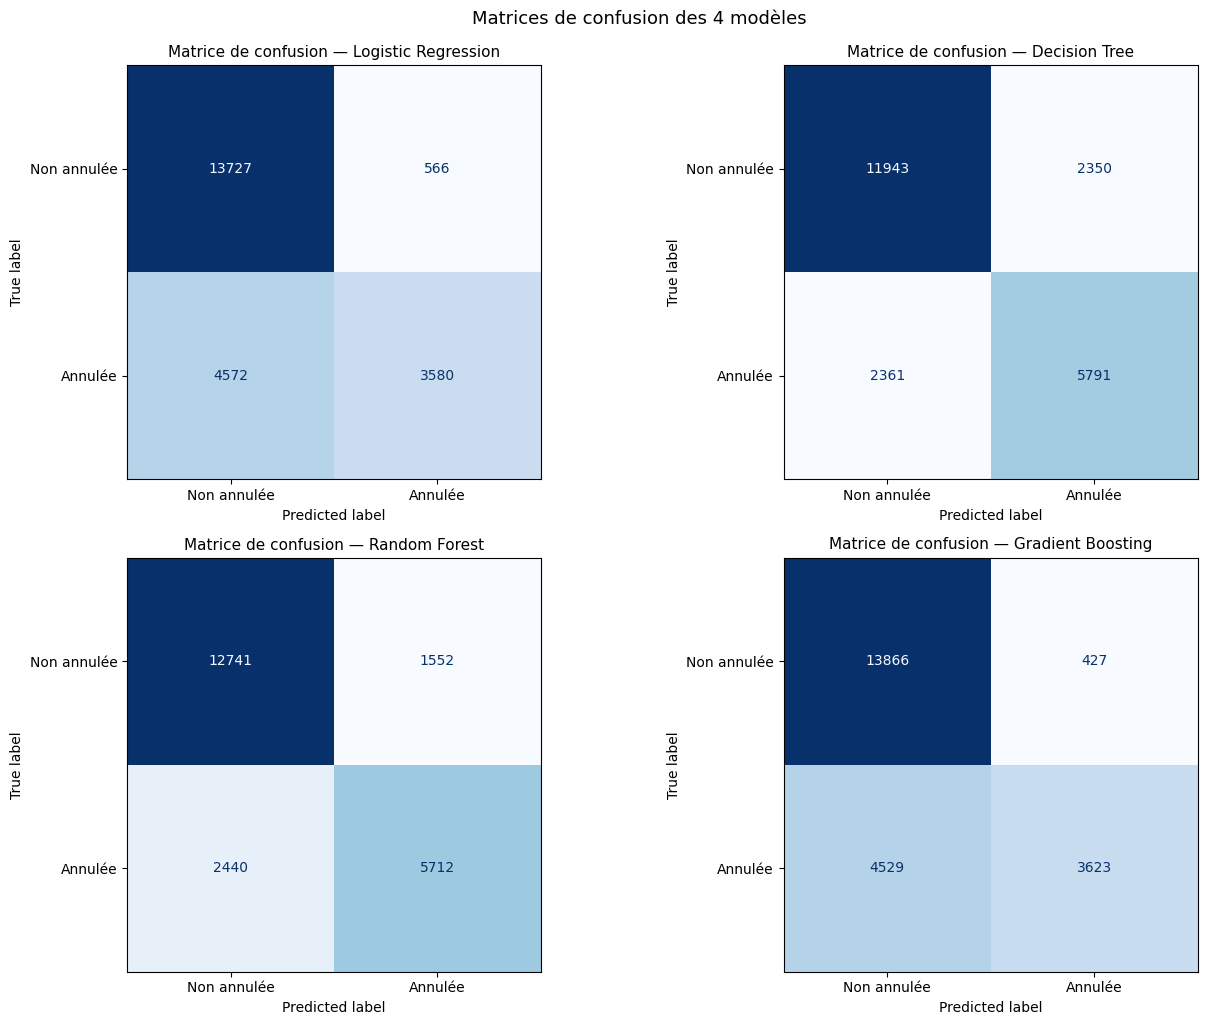

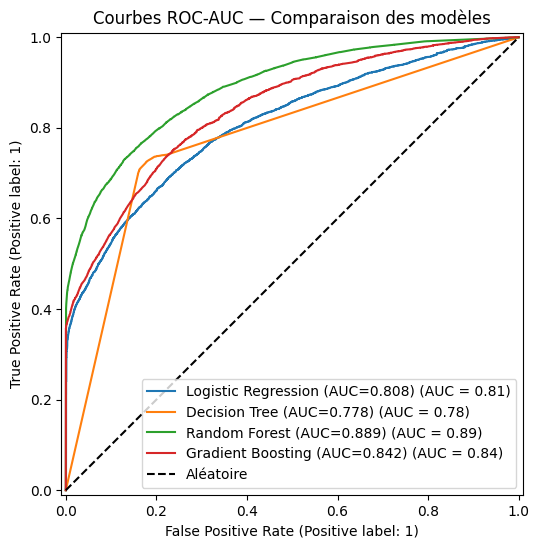

In [ ]:
from sklearn.metrics import RocCurveDisplay

# --- MATRICES DE CONFUSION (4 modèles) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non annulée', 'Annulée'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"Matrice de confusion — {name}", fontsize=11)

plt.tight_layout()
plt.suptitle("Matrices de confusion des 4 modèles", fontsize=13, y=1.02)
plt.show()

# --- COURBES ROC-AUC ---
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax.set_title("Courbes ROC-AUC — Comparaison des modèles")
ax.legend(loc='lower right')
plt.show()


## Importance des Variables & Identification du Meilleur Modèle

L'importance des variables permet d'identifier les facteurs les plus déterminants dans la prédiction des annulations. On utilise automatiquement le meilleur modèle selon le ROC-AUC, qui fournit un score d'importance basé sur la réduction d'impureté Gini.

In [ ]:
# === IDENTIFICATION DU MEILLEUR MODÈLE ===
best_model_name = df_results['ROC-AUC'].idxmax()
best_roc = df_results.loc[best_model_name, 'ROC-AUC']
best_f1  = df_results.loc[best_model_name, 'F1-Score']

print(f"Meilleur modèle retenu : {best_model_name}")
print(f"  → ROC-AUC : {best_roc:.4f}")
print(f"  → F1-Score : {best_f1:.4f}")

# === GRAPHIQUE : IMPORTANCE DES FEATURES (meilleur modèle) ===
best_pipeline = results[best_model_name]['pipeline']
best_clf      = best_pipeline.named_steps['classifier']

ohe_features = best_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(features_cat).tolist()

all_feature_names = features_num + ohe_features

if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
    plt.title(f"Top 15 variables les plus importantes — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\nTop 5 variables prédictives :")
    for i, row in feat_imp_df.head(5).iterrows():
        print(f"  {row['Feature']:<40} → {row['Importance']:.4f}")
else:
    print("Ce modèle ne fournit pas de feature_importances_.")


## Extension Avancée : Séparation Temporelle

**Pourquoi tester une séparation temporelle ?**  
La séparation aléatoire (random split) peut introduire une fuite d'information temporelle : le modèle voit des réservations de 2017 dans le train et prédit des réservations de 2016 dans le test, ce qui est irréaliste. Une séparation chronologique simule les conditions réelles de déploiement du modèle — on entraîne sur le passé et on prédit l'avenir.

On utilise `arrival_date_year` pour créer un split approximatif :
- **Train** : années 2015–2016
- **Test** : année 2017

In [ ]:
# Séparation temporelle : train = 2015-2016, test = 2017
X_full = df[features_num + features_cat].copy()
y_full = df['is_canceled'].copy()
years = df['arrival_date_year']

X_train_temp = X_full[years < 2017]
y_train_temp = y_full[years < 2017]
X_test_temp  = X_full[years == 2017]
y_test_temp  = y_full[years == 2017]

print(f"Train temporel : {X_train_temp.shape} | Test temporel : {X_test_temp.shape}")
print(f"Taux annulation train : {y_train_temp.mean():.2%} | test : {y_test_temp.mean():.2%}")

# Entraîner le meilleur modèle (Random Forest) sur la séparation temporelle
from sklearn.metrics import f1_score, roc_auc_score

rf_temp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_temp_pipeline.fit(X_train_temp, y_train_temp)
y_pred_temp = rf_temp_pipeline.predict(X_test_temp)
y_proba_temp = rf_temp_pipeline.predict_proba(X_test_temp)[:, 1]

print("\n=== Random Forest — Séparation temporelle ===")
print(classification_report(y_test_temp, y_pred_temp, target_names=['Non annulée', 'Annulée']))
print(f"ROC-AUC temporel : {roc_auc_score(y_test_temp, y_proba_temp):.4f}")

# Comparaison résumée
roc_random = results['Random Forest']['roc_auc']
roc_temporal = roc_auc_score(y_test_temp, y_proba_temp)
print(f"\nComparaison ROC-AUC Random Forest :")
print(f"  Split aléatoire : {roc_random:.4f}")
print(f"  Split temporel  : {roc_temporal:.4f}")
print(f"  Écart           : {roc_random - roc_temporal:+.4f} (un écart positif indique un léger optimisme du split aléatoire)")

## Recommandations Métier

Sur la base des résultats de nos modèles et de l'analyse exploratoire, nous formulons des recommandations concrètes et actionnables pour réduire les annulations hôtelières.

In [ ]:
# === RÉSUMÉ CHIFFRÉ POUR LES RECOMMANDATIONS ===

deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean().round(3) * 100
print("Taux d'annulation par type de dépôt :")
print(deposit_cancel.to_string())

hotel_cancel = df.groupby('hotel')['is_canceled'].mean().round(3) * 100
print(f"\nTaux d'annulation par type d'hôtel :")
print(hotel_cancel.to_string())

segment_cancel = df.groupby('market_segment')['is_canceled'].mean().round(3) * 100
segment_cancel = segment_cancel.sort_values(ascending=False)
print(f"\nTaux d'annulation par segment de marché :")
print(segment_cancel.to_string())

lead_cancel = df.groupby('is_canceled')['lead_time'].mean().round(1)
print(f"\nLead time moyen : Non annulé={lead_cancel[0]}j | Annulé={lead_cancel[1]}j")


In [ ]:
# === AFFICHAGE DES RECOMMANDATIONS BASEES SUR LES RESULTATS ===

city_rate        = hotel_cancel.get('City Hotel', 0)
resort_rate      = hotel_cancel.get('Resort Hotel', 0)
no_dep_rate      = deposit_cancel.get('No Deposit', 0)
non_ref_rate     = deposit_cancel.get('Non Refund', 0)
lead_no_cancel   = lead_cancel[0]
lead_cancel_val  = lead_cancel[1]
top_segment      = segment_cancel.index[0]
top_segment_rate = segment_cancel.iloc[0]

print('=' * 65)
print('  RECOMMANDATIONS METIER - REDUCTION DES ANNULATIONS HOTELIERES')
print('=' * 65)

reco1 = f"""
RECOMMANDATION 1 - Politique de depot differenciee
{'=' * 51}
Constat : Les reservations sans depot ('No Deposit') ont un taux
d'annulation de {no_dep_rate:.1f}%, contre seulement {non_ref_rate:.1f}%
pour les reservations non remboursables ('Non Refund').
Action   : Exiger un depot partiel (ex : 20-30%) pour les reservations
effectuees plus de 30 jours a l'avance, notamment sur les canaux en ligne.
"""

reco2 = f"""
RECOMMANDATION 2 - Gestion du lead_time eleve
{'=' * 46}
Constat : Le delai moyen avant arrivee est de {lead_no_cancel:.0f} jours
pour les clients qui honorent leur reservation, contre {lead_cancel_val:.0f} jours
pour ceux qui annulent.
Action   : Mettre en place des e-mails de confirmation automatiques
a J-60, J-30 et J-7 pour les reservations a fort lead_time.
"""

reco3 = f"""
RECOMMANDATION 3 - Strategie par type d'hotel
{'=' * 46}
Constat : Le City Hotel affiche {city_rate:.1f}% d'annulations vs
{resort_rate:.1f}% pour le Resort Hotel.
Action   : Appliquer une politique d'overbooking plus agressive sur
le City Hotel et proposer des tarifs non remboursables attractifs.
"""

reco4 = f"""
RECOMMANDATION 4 - Segmentation par canal de distribution
{'=' * 57}
Constat : Le segment '{top_segment}' presente le taux d'annulation
le plus eleve : {top_segment_rate:.1f}%.
Action   : Renegocier les conditions contractuelles avec ce segment
(delais d'annulation plus courts, penalites renforcees).
"""

reco5 = f"""
RECOMMANDATION 5 - Utilisation du modele en production
{'=' * 54}
Constat : Notre meilleur modele ({best_model_name}) atteint un
ROC-AUC de {best_roc:.4f} et un F1-Score de {best_f1:.4f}.
Action   : Integrer ce modele dans le systeme de reservation pour
scorer chaque nouvelle reservation en temps reel et declencher
automatiquement des actions preventives (depot requis, offre de
modification, contact client) sur les reservations a risque eleve.
"""

for reco in [reco1, reco2, reco3, reco4, reco5]:
    print(reco)

print('=' * 65)
